# Notebook 03 CLV (Customer Life Value)


Quiero responder dos preguntas:
1. cuánto dinero va a generar cada
hogar en los próximos 12 meses,
2. qué hogares están en riesgo de
dejar de comprar.

No pude usar un modelo de churn clásico porque el dataset no tiene un evento de baja observable — es un entorno no contractual.


Esto es más difícil de lo que parece porque en un supermercado
nadie "se da de baja" formalmente. Un hogar que lleva 4 meses sin
venir puede haberse ido a la competencia, o simplemente estar de
vacaciones — no hay forma de saberlo con certeza.

La técnica estándar para esto es combinar dos modelos:
 - BG/NBD: estima cuántas veces comprará un hogar y qué probabilidad tiene de seguir "vivo" (activo)
 - Gamma-Gamma: estima cuánto gastará en cada compra
- Multiplicando ambas cosas se obtiene el CLV.

Ressumen: No pude usar un modelo de churn clásico porque el dataset no tiene un evento de baja observable , es un entorno no contractual . Por eso usé BG/NBD, que en vez de clasificar directamente infiere la probabilidad de que un cliente siga activo a partir de su patrón histórico de compra.


In [1]:
!pip install lifetimes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 17.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

RUTA_PROCESADOS = '/content/drive/MyDrive/UCM -master Data Science/TFM/data/processed/'
RUTA_FIGURAS = '/content/drive/MyDrive/UCM -master Data Science/TFM/figuras/'

trans = pd.read_csv(RUTA_PROCESADOS + 'transactions_clean.csv')

Mounted at /content/drive


# Cosntruccion BG/NBD

BG/NBD utiliza las 4 variables siguientes:

- frequency = número de compras REPETIDAS
               (NO cuenta la primera compra)
               Un hogar que vino 5 veces entonces  frequency = 4

- recency   = días entre la PRIMERA y la ÚLTIMA compra
               (NO es "días desde la última compra")
               Vino el día 10 y el día 200 entonces  recency = 190

 - T         = días entre la PRIMERA compra y HOY
               (la "edad" del cliente en el dataset)
               Vino por primera vez el día 10, hoy es 711 entonces T = 701

 - monetary  = gasto medio por compra repetida

 El modelo compara recency con T. Si un cliente lleva mucho
 tiempo en el dataset (T alto) pero su última compra fue hace
tiempo (recency bajo respecto a T), es señal de que se ha ido.

Ejemplo:
-   Cliente A: T=700, recency=690 : compró hace poco → VIVO
-   Cliente B: T=700, recency=100 :  lleva 600 días sin venir → MUERTO

In [3]:

#Se muestran los días que compró el hogar seleccionado.
hogar_ejemplo = trans[trans['household_key'] == 1]
dias_compra = sorted(hogar_ejemplo['DAY'].unique())

dias_compra[:10]

[np.int64(51),
 np.int64(67),
 np.int64(88),
 np.int64(94),
 np.int64(101),
 np.int64(108),
 np.int64(111),
 np.int64(128),
 np.int64(137),
 np.int64(146)]

In [4]:
print("dias compra:",len(dias_compra))
print("primera compra:", min(dias_compra))
print("ultima compra:", max(dias_compra))
print("ultimo dia dataset:", trans['DAY'].max())

dias compra: 78
primera compra: 51
ultima compra: 706
ultimo dia dataset: 711


El hogar 1 compró prácticamente hasta el último día del dataset. Está claramente vivo.

# Construir la tabla RFM para BG/NBD

In [5]:
from lifetimes.utils import summary_data_from_transaction_data

visitas = trans.groupby(['household_key', 'DAY']).agg(
    gasto_visita = ('SALES_VALUE', 'sum')
).reset_index()

len(visitas), len(trans)

(225284, 2576815)

In [6]:
visitas[visitas['household_key'] == 1].head()

,household_key,DAY,gasto_visita
0,1,51,78.66
1,1,67,41.10
2,1,88,26.90
3,1,94,63.43
4,1,101,53.45


In [7]:
ultimo_dia = trans['DAY'].max()

rfm_bgnbd = summary_data_from_transaction_data(
    transactions = visitas,
    customer_id_col = 'household_key',
    datetime_col = 'DAY',
    monetary_value_col = 'gasto_visita',
    observation_period_end = ultimo_dia,
    freq = 'D'
)

rfm_bgnbd.head(10)

,frequency,recency,T,monetary_value
household_key,,,,
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0


In [8]:
rfm_bgnbd.describe()

,frequency,recency,T,monetary_value
count,2500.0,2500.0,2500.0,2500.0
mean,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0


La librería lifetimes tiene una función que construye automáticamente
la tabla en el formato que necesita BG/NBD
(summary_data_from_transaction_data), pero antes tengo que preparar
los datos: quiero una fila por hogar y día de compra, no por
producto. Si un hogar compra 20 productos en una sola visita, eso
cuenta como una compra, no como 20,  por eso agrupo por
household_key y DAY antes de pasarle los datos a la función.

El resultado sale completamente a cero para las 2.500 filas. Algo
falló. Investigando, creo que el problema es que
summary_data_from_transaction_data espera fechas reales (formato
datetime), no números enteros. Mi columna DAY son enteros del 1 al
711, y la función probablemente intenta interpretarlos como fechas
sin conseguirlo, devolviendo ceros en vez de dar un error que me
avisara.

La solución es convertir los días en fechas ficticias: elijo una
fecha de inicio cualquiera (por ejemplo, 1 de enero de 2023) y le
sumo cada día. El día 51 pasa a ser 2023-02-20, el día 706 pasa a
ser 2024-12-07. La fecha exacta no importa, lo único que importa es
que las distancias entre fechas se mantengan iguales que las
distancias entre los números de día originales.

In [9]:
FECHA_INICIO = pd.Timestamp('2023-01-01')
visitas['fecha'] = FECHA_INICIO + pd.to_timedelta(visitas['DAY'], unit='D')

visitas[visitas['household_key'] == 1].head()

,household_key,DAY,gasto_visita,fecha
0,1,51,78.66,2023-02-21
1,1,67,41.10,2023-03-09
2,1,88,26.90,2023-03-30
3,1,94,63.43,2023-04-05
4,1,101,53.45,2023-04-12


In [10]:
fecha_fin = visitas['fecha'].max()

rfm_bgnbd = summary_data_from_transaction_data(
    transactions = visitas,
    customer_id_col = 'household_key',
    datetime_col = 'fecha',
    monetary_value_col = 'gasto_visita',
    observation_period_end = fecha_fin,
    freq = 'D'
)

rfm_bgnbd.describe()

,frequency,recency,T,monetary_value
count,2500.000000,2500.00000,2500.000000,2500.000000
mean,89.113600,619.22360,644.799600,35.936760
std,76.259702,74.50271,39.509794,21.060330
min,0.000000,0.00000,40.000000,0.000000
25%,33.000000,599.00000,616.000000,21.118571
50%,69.000000,626.00000,642.000000,31.488969
75%,123.000000,661.00000,675.000000,45.948288
max,520.000000,710.00000,710.000000,188.212254


Ahora sí salen valores distintos de cero. Para comprobar que está
bien, verifico el hogar 1 a mano: había calculado antes que su
frequency debería ser 77, recency 655 y T 660. Si estos números
coinciden con lo que da la función ahora, confío en el resultado
para el resto de hogares.

In [11]:
hogar1 = rfm_bgnbd.loc[1]
hogar1

,1
frequency,77.000000
recency,655.000000
T,660.000000
monetary_value,55.214286


Ahora confío en el resultado

In [12]:
hogar1['frequency'] == 77 and hogar1['recency'] == 655 and hogar1['T'] == 660

np.True_

In [13]:
#Conteo de hogares con una sola compra ya que efrequency son las compras repetidas sin contar la primera compra
(rfm_bgnbd['frequency'] == 0).sum()

np.int64(3)

Solo 3 hogares están en esta situación, un porcentaje insignificante

# Entrenar BG/NBD

In [14]:
from lifetimes import BetaGeoFitter
# Crear el modelo
bgf = BetaGeoFitter(penalizer_coef=0.001)
# entrenar
bgf.fit(
    frequency = rfm_bgnbd['frequency'],
    recency = rfm_bgnbd['recency'],
    T = rfm_bgnbd['T']
)

bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,1.465305,0.038861,1.389138,1.541472
alpha,10.511906,0.329038,9.866991,11.156820
a,0.009665,0.001264,0.007188,0.012143
b,1.987209,0.306889,1.385706,2.588711


Entreno BG/NBD con los tres valores que calculé antes: frequency,
recency y T. El modelo va a estimar dos cosas para el conjunto de
hogares: con qué frecuencia compra la gente cuando está activa, y
qué probabilidad hay de que un hogar "se dé de baja" (deje de
comprar) después de cada visita.

  r y alpha --> describen cómo varía la FRECUENCIA de compra
               entre los distintos hogares

  a y b      -->describen la probabilidad de ABANDONO
               (que un hogar deje de comprar)

- Uso el penalizer_coef igual 0.001, que es el valor que recomienda la
documentación de la librería.Este penalizador evita que se ajuste demasiado a los datos (overfitting).

- El modelo devuelve cuatro parámetros (r, alpha, a, b) que describen
matemáticamente la distribución de frecuencia de compra y de
probabilidad de abandono en el conjunto de hogares.


El parámetro a=0.0097 es muy cercano a cero, lo que indica que la
probabilidad de abandono tras cada compra es muy baja. Parace razonable puesto que son hogares con tarjeta de fidelización en su supermercado
habitual, no compradores ocasionales.

El cociente r/alpha (1.465/10.51 = 0.14) da una tasa media de
compra de unas 0.14 veces al día, es decir, una visita cada 7 días
aproximadamente.
Esto coincide con lo que vi en el EDA (78 visitas
en 2 años, sobre una cada 9 días), así que el modelo está
capturando un comportamiento coherente con lo que ya sabía de los
datos.
POr tanto el modelo converge bien.

# Predecir compras en los próximos 90 días

Con el modelo ya entrenado, calculo dos predicciones por hogar:
cuántas compras espero que haga en los próximos 90 días, y qué
probabilidad tiene de seguir activo (no haberse ido a la
competencia). Reviso también el top 5 de hogares más activos y
cuántos hogares tienen menos de un 30% de probabilidad de seguir
activos, que serían candidatos a una campaña de reactivación.

In [15]:
DIAS_FUTURO = 90

rfm_bgnbd['compras_esperadas_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    DIAS_FUTURO,
    rfm_bgnbd['frequency'],
    rfm_bgnbd['recency'],
    rfm_bgnbd['T']
)

rfm_bgnbd['prob_vivo'] = bgf.conditional_probability_alive(
    rfm_bgnbd['frequency'],
    rfm_bgnbd['recency'],
    rfm_bgnbd['T']
)

rfm_bgnbd[['compras_esperadas_90d', 'prob_vivo']].describe()

,compras_esperadas_90d,prob_vivo
count,2.500000e+03,2.500000e+03
mean,1.208217e+01,9.641116e-01
std,1.055967e+01,1.671657e-01
min,8.284731e-31,3.434654e-32
25%,4.421968e+00,9.988509e-01
50%,9.237934e+00,9.996737e-01
75%,1.671348e+01,9.998629e-01
max,7.111526e+01,1.000000e+00


In [16]:
rfm_bgnbd.nlargest(5, 'compras_esperadas_90d')

,frequency,recency,T,monetary_value,compras_esperadas_90d,prob_vivo
household_key,,,,,,
900,520.0,649.0,649.0,31.547212,71.115263,0.999981
1510,503.0,629.0,629.0,22.285030,70.947030,0.999981
1795,493.0,621.0,622.0,19.777201,70.308110,0.999957
2337,443.0,595.0,597.0,26.377065,65.794223,0.999906
762,440.0,625.0,625.0,20.402000,62.477193,0.999978


In [17]:
(rfm_bgnbd['prob_vivo'] < 0.3).sum()

np.int64(71)

El hogar más activo (900) tiene 520 compras en 649 días, prácticamente
compra a diario, y el modelo le predice 71 visitas en los próximos
90 días. Solo 71 hogares (2.8%) tienen menos de un 30% de probabilidad de seguir activos, un número bajo, lo que confirma otra vez la alta fidelidad de esta base de clientes que ya había visto.

# Gamma-Gamma: verificar

Gamma-Gamma predice cuánto va a gastar un hogar en cada compra
(complementa a BG/NBD, que predice cuántas veces va a comprar).
Pero para poder usarlo necesito comprobar un supuesto: que la
frecuencia de compra y el gasto por compra sean independientes.
Si un hogar que compra mucho también gastara sistemáticamente más
por visita (o menos), el modelo estaría contando ese efecto dos
veces y el CLV saldría inflado.

Para verificarlo, calculo la correlación entre frequency y
monetary_value. Si está por debajo de 0.3 en valor absoluto, doy
el supuesto por cumplido.

También excluyo aquí a los hogares con frequency=0 (solo una
compra), porque Gamma-Gamma necesita al menos una compra repetida
para tener información sobre el gasto medio de ese hogar.

In [18]:
# Gamma-Gamma solo funciona con hogares con compras repetidas
rfm_gg = rfm_bgnbd[rfm_bgnbd['frequency'] > 0].copy()

len(rfm_bgnbd), len(rfm_gg)

(2500, 2497)

In [19]:
correlacion = rfm_gg[['frequency', 'monetary_value']].corr().iloc[0, 1]
correlacion

np.float64(-0.016877296927429074)

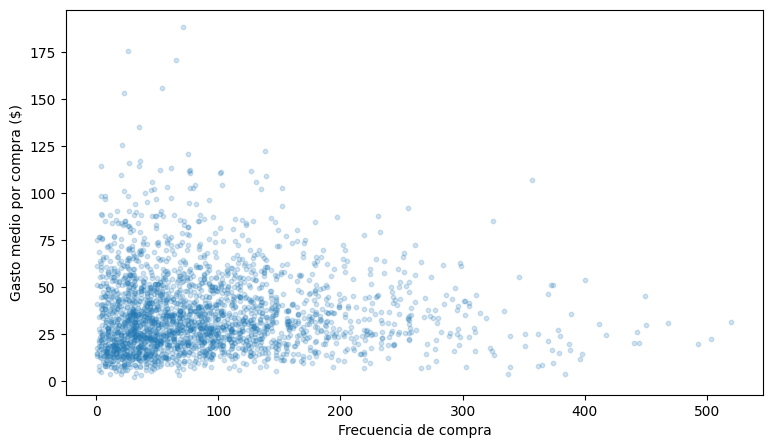

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(rfm_gg['frequency'], rfm_gg['monetary_value'], alpha=0.2, s=10)
ax.set_xlabel('Frecuencia de compra')
ax.set_ylabel('Gasto medio por compra ($)')
plt.show()

La correlación sale -0.017, prácticamente cero. El supuesto se
cumple con holgura, así que puedo usar Gamma-Gamma con confianza.

# Entreno Gamma-Gamma

Entreno Gamma-Gamma con los hogares que compraron más de una vez.
Este modelo predice cuánto va a gastar cada hogar en su próxima
compra.

Si un hogar solo compró 2 veces, esa media puede ser rara (por
ejemplo, si una de esas 2 compras fue muy grande por casualidad).
El modelo lo compensa "tirando" un poco esa media hacia la media
general de todos los hogares. Cuantas menos compras tenga un hogar,
más lo corrige, e nel caso que  si tiene muchísimas compras, entonces no lo toca porque ya se puede confiar en su propia media.

Para ver si el modelo funciona bien, comparo el gasto medio real
(histórico) con el gasto medio que predice el modelo. Si se parecen,
es buena señal.

In [21]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    frequency = rfm_gg['frequency'],
    monetary_value = rfm_gg['monetary_value']
)

ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,7.456939,0.247739,6.971370,7.942508
q,2.291107,0.060449,2.172626,2.409588
v,7.494922,0.251606,7.001774,7.988069


In [22]:
rfm_gg['gasto_esperado'] = ggf.conditional_expected_average_profit(
    rfm_gg['frequency'],
    rfm_gg['monetary_value']
)

rfm_gg[['monetary_value', 'gasto_esperado']].mean()

,0
monetary_value,35.979936
gasto_esperado,36.020428


El gasto medio  predicho  (36.02 $ ) es prácticamente idéntico al
histórico real (35.98$). El modelo está bien calibrado.

Quiero ver si el efecto de "corrección hacia la media" que
mencioné antes se nota realmente en los datos. Separo los hogares
en grupos según cuántas compras han hecho, y comparo el gasto real
con el gasto que predice el modelo en cada grupo. Si la corrección
funciona como espero, los hogares con pocas compras deberían tener
una corrección más grande que los que tienen muchas.

In [23]:
rfm_gg['grupo_frecuencia'] = pd.cut(
    rfm_gg['frequency'],
    bins=[0, 10, 50, 150, 10000],
    labels=['1-10 compras', '11-50 compras', '51-150 compras', '150+ compras']
)

rfm_gg.groupby('grupo_frecuencia')[['monetary_value', 'gasto_esperado']].mean()

,monetary_value,gasto_esperado
grupo_frecuencia,,
1-10 compras,35.634517,35.893015
11-50 compras,34.941742,34.997280
51-150 compras,37.215483,37.227664
150+ compras,34.830387,34.837089


In [24]:
comparacion = rfm_gg.groupby('grupo_frecuencia')[['monetary_value', 'gasto_esperado']].mean()
comparacion['correccion_pct'] = (comparacion['gasto_esperado'] - comparacion['monetary_value']) / comparacion['monetary_value'] * 100

comparacion

,monetary_value,gasto_esperado,correccion_pct
grupo_frecuencia,,,
1-10 compras,35.634517,35.893015,0.725415
11-50 compras,34.941742,34.997280,0.158942
51-150 compras,37.215483,37.227664,0.032732
150+ compras,34.830387,34.837089,0.019240


Se ve el patrón esperado:
- el grupo de 1-10 compras tiene la corrección más alta (+0.7%), y baja según sube el número de compras hasta quedar casi en 0% en el grupo de 150+ compras.

Si tuviera clientes con solo 1 o 2 compras el efecto probablemente
sería mucho más grande.

# Calculo del CLV a 12 meses

Con las dos piezas ya listas (BG/NBD para saber cuántas compras
espero, Gamma-Gamma para saber cuánto gasta en cada una), calculo
el CLV a 12 meses: compras esperadas multiplicadas por gasto
esperado por compra.


In [25]:
rfm_gg['recency'] = rfm_bgnbd.loc[rfm_gg.index, 'recency']
rfm_gg['T'] = rfm_bgnbd.loc[rfm_gg.index, 'T']

rfm_gg['clv_12m'] = ggf.customer_lifetime_value(
    transaction_prediction_model = bgf,
    frequency = rfm_gg['frequency'],
    recency = rfm_gg['recency'],
    T = rfm_gg['T'],
    monetary_value = rfm_gg['monetary_value'],
    time = 12,
    freq = 'D',
    discount_rate = 0.01
)

rfm_gg['clv_12m'].describe()

,clv_12m
count,2.497000e+03
mean,1.623137e+03
std,1.738252e+03
min,8.124446e-29
25%,4.562416e+02
50%,1.070552e+03
75%,2.234003e+03
max,2.107687e+04


In [26]:
rfm_gg['clv_12m'].describe()

,clv_12m
count,2.497000e+03
mean,1.623137e+03
std,1.738252e+03
min,8.124446e-29
25%,4.562416e+02
50%,1.070552e+03
75%,2.234003e+03
max,2.107687e+04


In [27]:
rfm_gg['clv_12m'].sum()

np.float64(4052972.5383208385)

In [28]:
#suma total de cartera
rfm_gg['clv_12m'].sum()

np.float64(4052972.5383208385)

In [29]:
#comprobación de orden de magnitud
gasto_medio_anual_real = rfm_gg['monetary_value'].mean() * (rfm_gg['frequency'].mean() / (rfm_gg['T'].mean() / 365))
gasto_medio_anual_real, rfm_gg['clv_12m'].mean()

(np.float64(1817.1255806474314), np.float64(1623.1367794636917))

hago una comprobación básica de sentido común: calculo a mano, de forma aproximada, cuánto gasta un hogar al año según su historial real, y lo comparo con el CLV que predice el modelo. El CLV medio (1,623$) sale un poco por debajo del gasto anual histórico aproximado (1,817$), lo cual tiene sentido.

In [30]:
#top 10 hogares
rfm_gg.nlargest(10, 'clv_12m')[['frequency', 'monetary_value', 'clv_12m']]

,frequency,monetary_value,clv_12m
household_key,,,
1023,357.0,107.297563,21076.871076
1609,325.0,85.319138,13806.727314
2322,255.0,92.389804,12173.070244
1453,400.0,53.962600,11684.318394
1430,231.0,88.022251,10674.582309
707,346.0,55.245636,10453.313667
400,232.0,79.585862,10214.581757
1653,372.0,51.262177,10211.366747
2459,449.0,45.587439,10056.507046


In [31]:
# Calculo el 20% de los hogares cuanto corresponden en términos %

clv_ordenado = rfm_gg['clv_12m'].sort_values(ascending=False)
top20pct = int(len(clv_ordenado) * 0.20)

clv_ordenado.head(top20pct).sum() / clv_ordenado.sum() * 100

np.float64(53.86725404904533)

El 20% de hogares con más valor concentra el 53.9% del valor total
de la cartera. No todos los hogares trateremos igual en invertir en promociones.

# Segmentar hogares para acción comercial

 Usamos dos dimensiones:
 - VALOR :  CLV alto, medio o bajo (terciles)
 - RIESGO : probabilidad de seguir activo (alta o baja)

 Segmentación:

- 'Alto · Activo':     'Proteger. No necesitan descuento — ya compran.',
- 'Alto · En riesgo':  'PRIORIDAD MÁXIMA. Reactivar con oferta personalizada.',
- 'Medio · Activo':    'Hacer crecer. Cross-selling y aumento de cesta.',
- 'Medio · En riesgo': 'Reactivar con cupón de bajo coste.',
- 'Bajo · Activo':     'Mantener con comunicación de bajo coste.',
- 'Bajo · En riesgo':  'No invertir. El coste de recuperación supera el valor.

In [32]:
# probabilidad de estar vivo desde BG/NBD
rfm_gg['prob_vivo'] = rfm_bgnbd.loc[rfm_gg.index, 'prob_vivo']

#CLV en tres grupos (terciles)
rfm_gg['nivel_valor'] = pd.qcut(rfm_gg['clv_12m'], q=3, labels=['Bajo', 'Medio', 'Alto'])


#Umbral 0.7  clasificar por riesgo de abandono
rfm_gg['estado'] = np.where(rfm_gg['prob_vivo'] >= 0.7, 'Activo', 'En riesgo')
rfm_gg['segmento'] = rfm_gg['nivel_valor'].astype(str) + ' · ' + rfm_gg['estado']


#Combinar ambas dimensiones en un segmento
rfm_gg.groupby('segmento')['clv_12m'].agg(['count', 'mean', 'sum']).sort_values('sum', ascending=False)

,count,mean,sum
segmento,,,
Alto · Activo,831,3474.836884,2.887589e+06
Medio · Activo,830,1099.667713,9.127242e+05
Bajo · Activo,740,325.630818,2.409668e+05
Bajo · En riesgo,92,79.266983,7.292562e+03
Medio · En riesgo,3,781.645418,2.344936e+03
Alto · En riesgo,1,2054.581912,2.054582e+03


Quiero agrupar los hogares en segmentos con una recomendación distinta para cada uno.

Uso dos dimensiones
-  el nivel de valor (divido el CLV en tres grupos iguales con terciles) y el riesgo de abandono, usando la probabilidad de estar vivo que calculó BG/NBD.
-  Para el riesgo uso el umbral típico de 0.7: por encima, considero al hogar activo; por debajo, en riesgo.

Verificamos que el segmento "Alto · En riesgo", donde vale la pena invertir en reactivar, tiene un solo hogar. Me parece extraño.

- Creo que el problema es que esta base de clientes es muy fiel (ya
vi antes que el parámetro a del modelo era casi cero, y que solo
un 2.8% de hogares tenían menos de 30% de probabilidad de estar
vivos).

- El umbral de 0.7, puede que no
sirva aquí porque casi todos los hogares están muy por encima de
ese número. Voy a mirar cómo se distribuye realmente prob_vivo
para decidir un umbral que sí discrimine.

Recomendación COmercial por segmentos Numero hogares y clv12meses:

- Alto · Activo      -> Proteger. No necesitan descuento — ya compran.
                         (831 hogares, $2,887,589 en juego)

- Medio · Activo      ->  Hacer crecer. Cross-selling y aumento de cesta.
                         (830 hogares, $912,724 en juego)

- Bajo · Activo      -->  Mantener con comunicación de bajo coste.
                         (740 hogares, $240,967 en juego)

- Bajo · En riesgo    --> No invertir. El coste de recuperación supera el valor.
                         (92 hogares, $7,293 en juego)

- Medio · En riesgo    ->Reactivar con cupón de bajo coste.
                         (3 hogares, $2,345 en juego)

- Alto · En riesgo     ->PRIORIDAD MÁXIMA. Reactivar con oferta personalizada.
                         (1 hogares, $2,055 en juego)

# Segmentación corregida: riesgo relativo

El umbral de 0.7 no sirve en esta base porque casi todos los
hogares están muy por encima de ese valor (la probabilidad media
de estar vivo es 0.964). En vez de un umbral fijo, uso un criterio
relativo: clasifico como "en riesgo" al 20% de hogares con menor
probabilidad de estar vivos, sean los que sean.

Tiene sentido además desde el punto de vista de negocio: el
presupuesto para reactivar clientes es limitado, así que lo que
importa no es el riesgo absoluto sino saber a cuáles de mis
hogares priorizar con los recursos que tengo.

In [33]:
umbral_riesgo = rfm_gg['prob_vivo'].quantile(0.20)
umbral_riesgo

np.float64(0.998227606965626)

In [34]:
rfm_gg['estado'] = np.where(rfm_gg['prob_vivo'] <= umbral_riesgo, 'En riesgo', 'Activo')
rfm_gg['segmento'] = rfm_gg['nivel_valor'].astype(str) + ' · ' + rfm_gg['estado']

resumen_segmentos = rfm_gg.groupby('segmento').agg(
    n_hogares = ('clv_12m', 'count'),
    clv_medio = ('clv_12m', 'mean'),
    clv_total = ('clv_12m', 'sum'),
).reset_index()

resumen_segmentos['pct_valor'] = resumen_segmentos['clv_total'] / resumen_segmentos['clv_total'].sum() * 100
resumen_segmentos.sort_values('clv_total', ascending=False)

,segmento,n_hogares,clv_medio,clv_total,pct_valor
0,Alto · Activo,784,3521.167254,2.760595e+06,68.112851
4,Medio · Activo,729,1109.791629,8.090381e+05,19.961598
2,Bajo · Activo,484,370.482925,1.793137e+05,4.424252
1,Alto · En riesgo,48,2688.518857,1.290489e+05,3.184056
5,Medio · En riesgo,104,1019.529236,1.060310e+05,2.616130
3,Bajo · En riesgo,348,198.119633,6.894563e+04,1.701113


El umbral sale en 0.9982 - es decir, para entrar en mi grupo de
"en riesgo" un hogar necesita tener un 99.82% de probabilidad de
seguir activo. Suena raro a primera vista, pero confirma lo fiel
que es esta base de clientes: incluso los "peores" hogares tienen
una probabilidad altísima de seguir comprando.

Con este criterio ya salen los 6 segmentos con volumen razonable
en cada uno. El segmento "Alto · En riesgo" tiene 48 hogares con
129.049$ de valor en juego (2.688$ por hogar de media) - ahí sí
tiene sentido invertir en una campaña de reactivación personalizada.

# Visualización

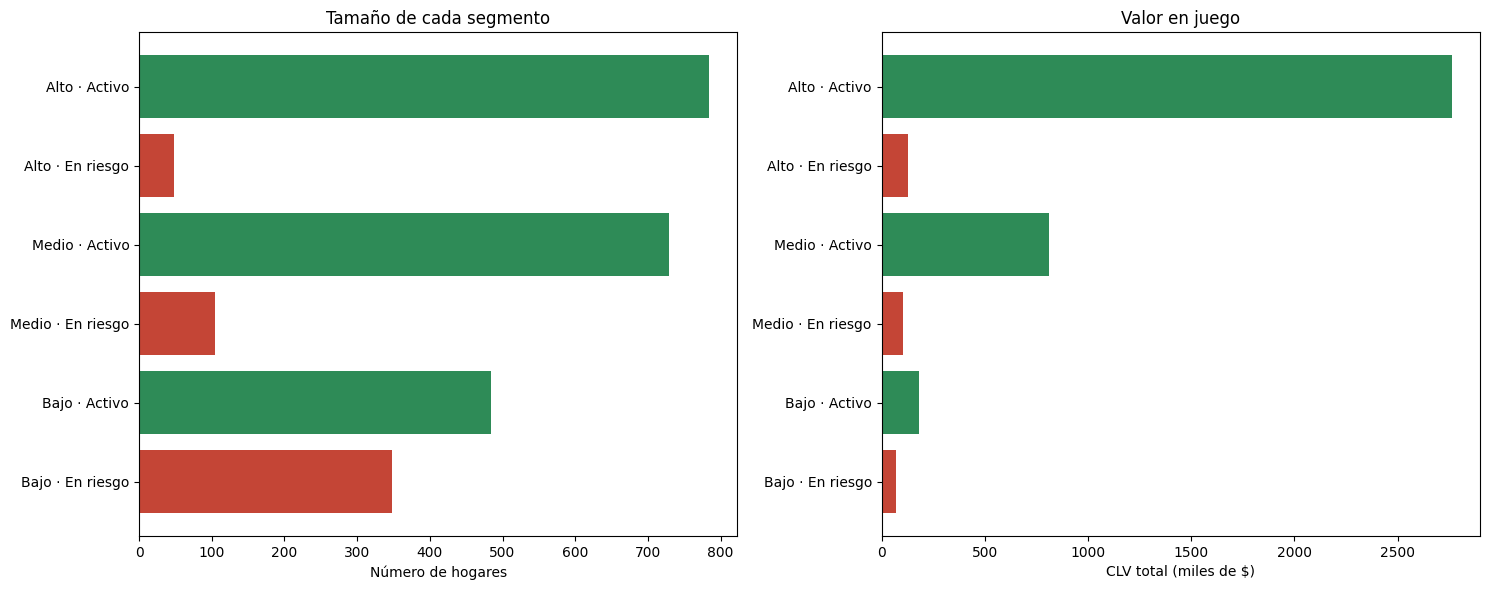

In [35]:
orden = ['Alto · Activo', 'Alto · En riesgo', 'Medio · Activo', 'Medio · En riesgo', 'Bajo · Activo', 'Bajo · En riesgo']
datos_graf = resumen_segmentos.set_index('segmento').reindex(orden).reset_index()
colores = ['#2E8B57' if 'Activo' in s else '#C44536' for s in datos_graf['segmento']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(datos_graf['segmento'], datos_graf['n_hogares'], color=colores)
ax1.set_xlabel('Número de hogares')
ax1.set_title('Tamaño de cada segmento')
ax1.invert_yaxis()

ax2.barh(datos_graf['segmento'], datos_graf['clv_total'] / 1000, color=colores)
ax2.set_xlabel('CLV total (miles de $)')
ax2.set_title('Valor en juego')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [36]:
fig.savefig(RUTA_FIGURAS + 'segmentacion_clv.png', dpi=150, bbox_inches='tight')

In [37]:
columnas_guardar = ['frequency', 'recency', 'T', 'monetary_value', 'gasto_esperado', 'prob_vivo', 'clv_12m', 'nivel_valor', 'estado', 'segmento']

clv_final = rfm_gg[columnas_guardar].copy()
clv_final.index.name = 'household_key'
clv_final.to_csv(RUTA_PROCESADOS + 'clv_por_hogar.csv')